### Student Placement Prediction

### Load Basic Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Exploration

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/placementdata.csv')

In [3]:
data.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [5]:
data.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


### Data Preprocessing

Droping irrelevent column

In [6]:
data = data.drop(columns=['StudentID'])

Encoding Categorical Variables

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()

In [9]:
categorical_cols = ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']
for cols in categorical_cols:
  data[cols] = le.fit_transform(data[cols])

Feature and Target Split

In [10]:
x = data.drop(columns=['PlacementStatus'])
y = data['PlacementStatus']

Data Splition

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Model Building and Comparison

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [18]:
results = {}

In [19]:
for name, model in models.items():
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  results[name] = acc
  print(f'{name} Accuracy: {acc}')

Logistic Regression Accuracy: 0.7945
KNN Accuracy: 0.772
Decision Tree Accuracy: 0.7375
Random Forest Accuracy: 0.787


Visualization of comparison

/tmp/ipykernel_639/1628748624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='hls')


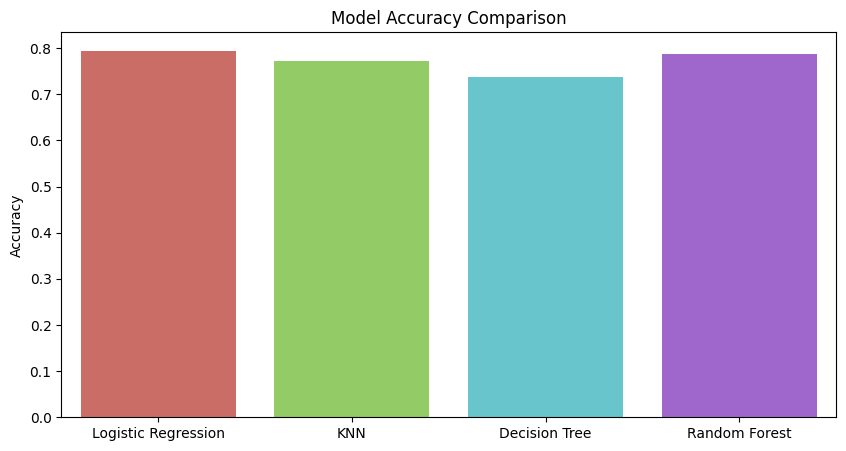

In [41]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='hls')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

--- Logistic Regression Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000

Confusion Matrix:


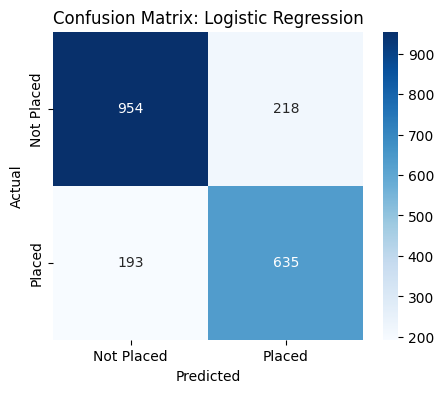



--- KNN Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1172
           1       0.73      0.72      0.72       828

    accuracy                           0.77      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000

Confusion Matrix:


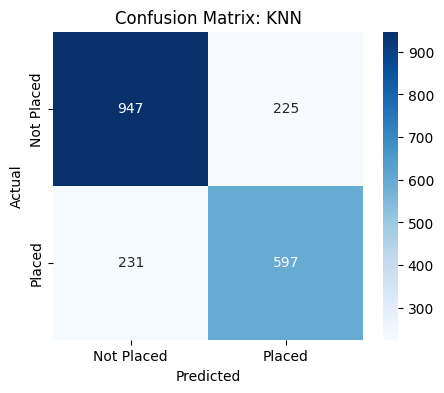



--- Decision Tree Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      1172
           1       0.67      0.68      0.67       828

    accuracy                           0.73      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000

Confusion Matrix:


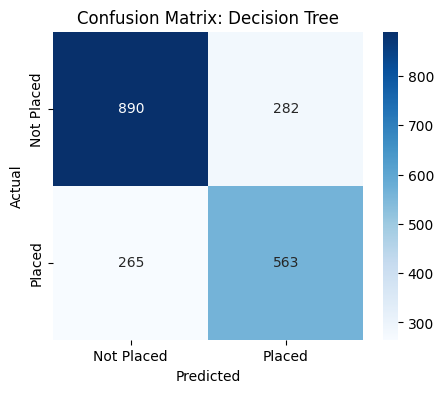



--- Random Forest Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1172
           1       0.75      0.71      0.73       828

    accuracy                           0.79      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.78      0.79      0.78      2000

Confusion Matrix:


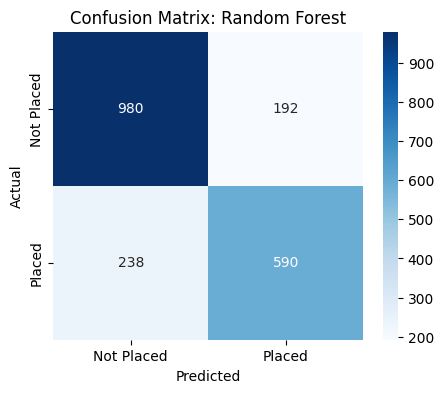

In [40]:
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print(f"--- {name} Results ---")

    # 1. Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # 2. Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)

    # Optional: Plot the confusion matrix visually for better impact
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Placed', 'Placed'],
                yticklabels=['Not Placed', 'Placed'])
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    print("\n")

### Hyperparameter Tuning

Grid Search for Random Forest

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [50, 100]})

In [23]:
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


### Saving the model and scaler

In [24]:
import joblib

In [25]:
joblib.dump(best_model, 'placement_model.h5')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


### Feature importance visualization

In [26]:
importances = best_model.feature_importances_
feature_names = x.columns

/tmp/ipykernel_639/3014386120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


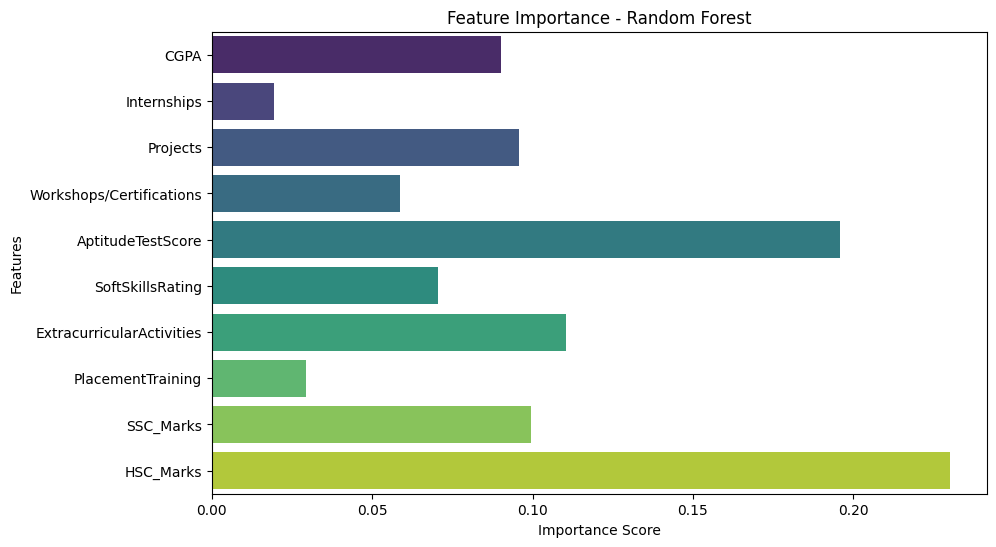

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Streamlit Implementation

Install the required libraries

In [35]:
!pip install streamlit pyngrok

Write the app.py code

In [37]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load the saved model and scaler
model = joblib.load('placement_model.h5')
scaler = joblib.load('scaler.pkl')

st.title("Student Placement Predictor")
st.write("Enter the following details to predict placement status:")

# Input fields - ensure the order matches the columns in your training data
cgpa = st.number_input("CGPA", 0.0, 10.0)
internships = st.number_input("Number of Internships", 0, 5)
projects = st.number_input("Number of Projects", 0, 10)
workshops = st.number_input("Workshops/Certifications", 0, 10)
aptitude = st.number_input("Aptitude Test Score", 0, 100)
soft_skills = st.number_input("Soft Skills Rating", 0.0, 5.0)
extracurricular = st.selectbox("Extracurricular Activities", [0, 1]) # 0: No, 1: Yes
training = st.selectbox("Placement Training", [0, 1]) # 0: No, 1: Yes
ssc = st.number_input("SSC Marks", 0, 100)
hsc = st.number_input("HSC Marks", 0, 100)

if st.button("Predict Placement"):
    # Combine inputs into a feature array
    input_features = np.array([[cgpa, internships, projects, workshops, aptitude,
                                soft_skills, extracurricular, training, ssc, hsc]])

    # Scale inputs using the loaded scaler
    scaled_features = scaler.transform(input_features)

    # Predict
    prediction = model.predict(scaled_features)

    # Display result
    result = "Placed" if prediction[0] == 1 else "Not Placed"
    st.subheader(f"Prediction: {result}")

Writing app.py


### Run the application

Run the Authentication

In [38]:
!ngrok authtoken 3G5vIxAH0OGEucvRughWivVppRx_6y4uMGSYuqMt2paeLNVNo

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


Launch the app

In [39]:
from pyngrok import ngrok

# Start the streamlit app in the background
!streamlit run app.py &>/dev/null&

# Connect ngrok to the streamlit port
public_url = ngrok.connect(8501)
print(f"Your app is live at: {public_url.public_url}")

Your app is live at: https://doorbell-illusion-maverick.ngrok-free.dev
